In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

EXPERIMENT = "atm_norm"
DATA_FILE = f"../data/processed/{EXPERIMENT}.nc"
ds = xr.open_dataset(DATA_FILE)

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [3]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (x_caa: 128, x_faa: 128, y_aca: 128, y_afa: 128, time: 12)
Coordinates:
  * x_caa    (x_caa) float64 1kB 0.02454 0.07363 0.1227 ... 6.16 6.21 6.259
  * x_faa    (x_faa) float64 1kB -7.513e-18 0.04909 0.09817 ... 6.185 6.234
  * y_aca    (y_aca) float64 1kB 0.02454 0.07363 0.1227 ... 6.16 6.21 6.259
  * y_afa    (y_afa) float64 1kB -7.513e-18 0.04909 0.09817 ... 6.185 6.234
  * time     (time) float64 96B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0 11.0
Data variables:
    Δx_caa   (x_caa) float32 512B ...
    Δx_faa   (x_faa) float32 512B ...
    Δy_aca   (y_aca) float32 512B ...
    Δy_afa   (y_afa) float32 512B ...
    u        (time, y_aca, x_faa) float32 786kB ...
    v        (time, y_afa, x_caa) float32 786kB ...
    ζ        (time, y_afa, x_faa) float32 786kB ...
Attributes:
    Julia:                      This file was generated using 
    Oceananigans:               This file was generated using Oceananigans v0...
    date:                       This file was generated on 2026-08-15T23:51:1...
    interval:                   100
    output iteration interval:  Output was saved every 100 iteration(s).
    schedule:                   IterationInterval

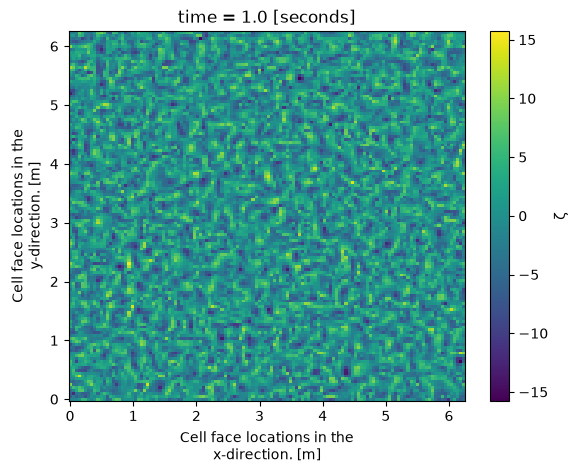

In [42]:
ds.ζ.isel(time=100).plot(cmap='viridis')
plt.show()

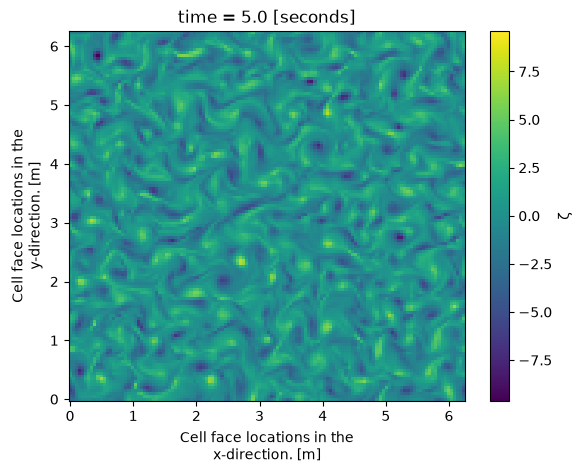

In [43]:
ds.ζ.isel(time=500).plot(cmap='viridis')
plt.show()

In [49]:
n_frames = len(ds.time)  # или ds.dims['time']

for k in range(n_frames):
    # Очищаем предыдущий вывод
    clear_output(wait=True)
    
    # Создаём новый график
    fig, ax = plt.subplots(figsize=(6,5))
    ds.ζ.isel(time=k*100).plot(ax=ax, cmap='viridis', add_colorbar=True)
    ax.set_title(f'Завихренность, время = {ds.time.values[k]*100:.2f}')
    plt.show()
    
    # Пауза между кадрами (в секундах)
    time.sleep(0.1)

KeyboardInterrupt: 